In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
import zipfile
zip_path = r"C:\Users\DELL\Downloads\patients_data_with_alerts.xlsx.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("patients_data_with_alerts.xlsx") as f:
        iomt = pd.read_excel(f)

In [3]:
iomt.head()

,Patient Number,Heart Rate (bpm),SpO2 Level (%),Systolic Blood Pressure (mmHg),Diastolic Blood Pressure (mmHg),Body Temperature (°C),Fall Detection,Predicted Disease,Data Accuracy (%),Heart Rate Alert,SpO2 Level Alert,Blood Pressure Alert,Temperature Alert
0,1,96,92,101,89,36.904680,No,Diabetes Mellitus,95,Normal,Normal,Normal,Normal
1,2,76,83,103,85,37.254129,Yes,Asthma,91,Normal,Low,Normal,Abnormal
2,3,92,88,123,70,36.539418,Yes,Asthma,86,Normal,Low,Normal,Normal
3,4,137,84,167,97,37.018767,Yes,Asthma,99,High,Low,High,Normal
4,5,76,81,175,80,37.328671,No,Normal,93,Normal,Low,High,Abnormal


In [4]:
iomt.tail()

,Patient Number,Heart Rate (bpm),SpO2 Level (%),Systolic Blood Pressure (mmHg),Diastolic Blood Pressure (mmHg),Body Temperature (°C),Fall Detection,Predicted Disease,Data Accuracy (%),Heart Rate Alert,SpO2 Level Alert,Blood Pressure Alert,Temperature Alert
49995,49996,118,96,103,65,37.112965,No,Asthma,91,High,Normal,Normal,Normal
49996,49997,61,81,101,71,36.457507,Yes,Normal,82,Normal,Low,Normal,Normal
49997,49998,63,91,166,67,37.083832,No,Hypertension,87,Normal,Normal,High,Normal
49998,49999,95,85,140,64,37.827279,Yes,Hypertension,90,Normal,Low,Normal,Abnormal
49999,50000,77,94,169,97,36.704183,Yes,Hypertension,93,Normal,Normal,High,Normal


In [5]:
iomt.shape

(50000, 13)

In [6]:
iomt.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient Number                   50000 non-null  int64  
 1   Heart Rate (bpm)                 50000 non-null  int64  
 2   SpO2 Level (%)                   50000 non-null  int64  
 3   Systolic Blood Pressure (mmHg)   50000 non-null  int64  
 4   Diastolic Blood Pressure (mmHg)  50000 non-null  int64  
 5   Body Temperature (°C)            50000 non-null  float64
 6   Fall Detection                   50000 non-null  str    
 7   Predicted Disease                50000 non-null  str    
 8   Data Accuracy (%)                50000 non-null  int64  
 9   Heart Rate Alert                 50000 non-null  str    
 10  SpO2 Level Alert                 50000 non-null  str    
 11  Blood Pressure Alert             50000 non-null  str    
 12  Temperature Alert            

In [7]:
iomt.duplicated().sum()

np.int64(0)

In [8]:
iomt.isnull().sum()

Patient Number                     0
Heart Rate (bpm)                   0
SpO2 Level (%)                     0
Systolic Blood Pressure (mmHg)     0
Diastolic Blood Pressure (mmHg)    0
Body Temperature (°C)              0
Fall Detection                     0
Predicted Disease                  0
Data Accuracy (%)                  0
Heart Rate Alert                   0
SpO2 Level Alert                   0
Blood Pressure Alert               0
Temperature Alert                  0
dtype: int64

In [9]:
iomt.describe()

,Patient Number,Heart Rate (bpm),SpO2 Level (%),Systolic Blood Pressure (mmHg),Diastolic Blood Pressure (mmHg),Body Temperature (°C),Data Accuracy (%)
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,104.509420,89.50182,139.539700,79.479160,37.001334,89.516940
std,14433.901067,25.922328,5.75763,23.069012,11.513794,0.576771,5.752263
min,1.000000,60.000000,80.00000,100.000000,60.000000,36.000016,80.000000
25%,12500.750000,82.000000,84.00000,120.000000,70.000000,36.505410,85.000000
50%,25000.500000,105.000000,90.00000,140.000000,79.000000,37.001556,90.000000
75%,37500.250000,127.000000,94.00000,160.000000,89.000000,37.501185,94.000000
max,50000.000000,149.000000,99.00000,179.000000,99.000000,37.999719,99.000000


The .value_counts() shows the number of patients with a particular predicted disease, fall detection, heart rates aleart, SpO₂ Level Alert, Blood pressure alert, and temperature alert.

In [10]:
iomt['Predicted Disease'].value_counts()

Predicted Disease
Asthma               10060
Diabetes Mellitus    10052
Normal               10013
Arrhythmia            9945
Hypertension          9930
Name: count, dtype: int64

In [11]:
iomt['Fall Detection'].value_counts()

Fall Detection
No     25117
Yes    24883
Name: count, dtype: int64

In [12]:
iomt['Heart Rate Alert'].value_counts()

Heart Rate Alert
High      27312
Normal    22688
Name: count, dtype: int64

In [13]:
iomt['SpO2 Level Alert'].value_counts()

SpO2 Level Alert
Normal    25019
Low       24981
Name: count, dtype: int64

In [14]:
iomt['Blood Pressure Alert'].value_counts()

Blood Pressure Alert
High      30140
Normal    19860
Name: count, dtype: int64

The dataset contains no hypotensive cases (Systolic BP minimum is 100mmHg), which may limit the model's ability to detect low blood pressure anomalies.

In [15]:
iomt['Temperature Alert'].value_counts()

Temperature Alert
Normal      27514
Abnormal    22486
Name: count, dtype: int64

In [16]:
iomt.describe(include='object')

C:\Users\DELL\AppData\Local\Temp\ipykernel_17720\1543556873.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  iomt.describe(include='object')


,Fall Detection,Predicted Disease,Heart Rate Alert,SpO2 Level Alert,Blood Pressure Alert,Temperature Alert
count,50000,50000,50000,50000,50000,50000
unique,2,5,2,2,2,2
top,No,Asthma,High,Normal,High,Normal
freq,25117,10060,27312,25019,30140,27514


**Data Visualization**

In this section, I will be visualizing vitals like Heart Rate (bpm), SpO2 Level (%), Systolic Blood Pressure (mmHg), and so on, using charts like histogram, box plots, count plots, and correlation heatmap. 

In [17]:
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (8, 4)

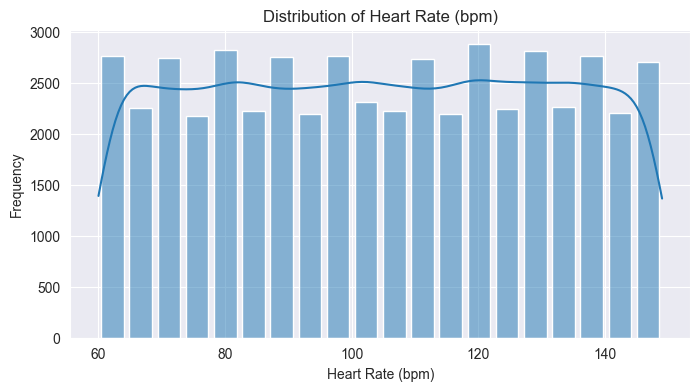

In [18]:
sns.histplot(data = iomt, x='Heart Rate (bpm)', bins=20, kde = True, shrink=0.8)
plt.title('Distribution of Heart Rate (bpm)')
plt.xlabel('Heart Rate (bpm)')
plt.ylabel('Frequency')
plt.show()

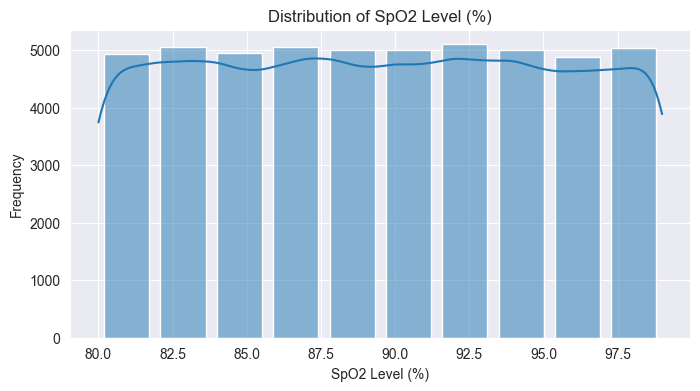

In [19]:
sns.histplot(data = iomt, x= 'SpO2 Level (%)', bins=10, kde = True, shrink=0.8)
plt.title('Distribution of SpO2 Level (%)')
plt.xlabel('SpO2 Level (%)')
plt.ylabel('Frequency')
plt.show()

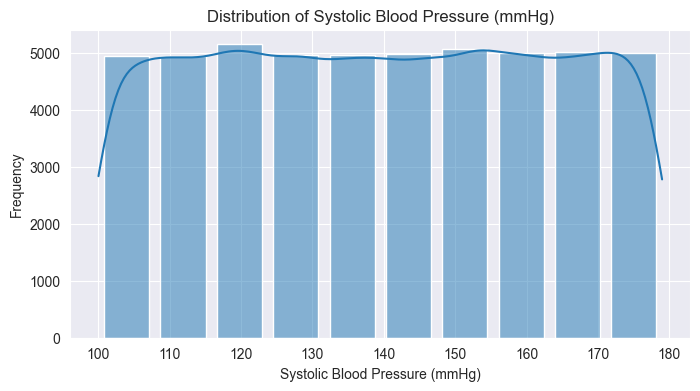

In [20]:
sns.histplot(data = iomt, x= 'Systolic Blood Pressure (mmHg)', bins=10, kde = True, shrink=0.8)
plt.title('Distribution of Systolic Blood Pressure (mmHg)')
plt.xlabel('Systolic Blood Pressure (mmHg)')
plt.ylabel('Frequency')
plt.show()

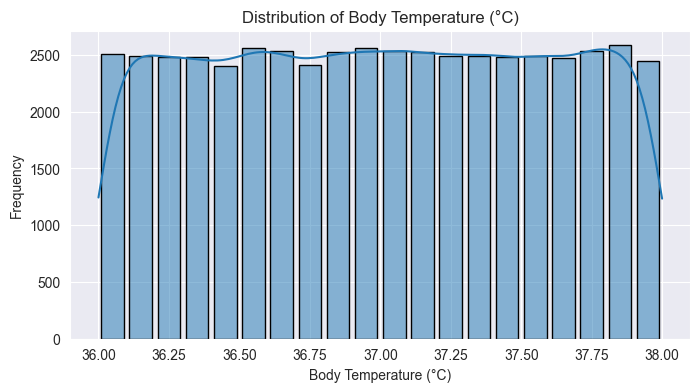

In [21]:
sns.histplot(data = iomt, x= 'Body Temperature (°C)', bins=20, kde = True, edgecolor='black', shrink=0.8)
plt.title('Distribution of Body Temperature (°C)')
plt.xlabel('Body Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

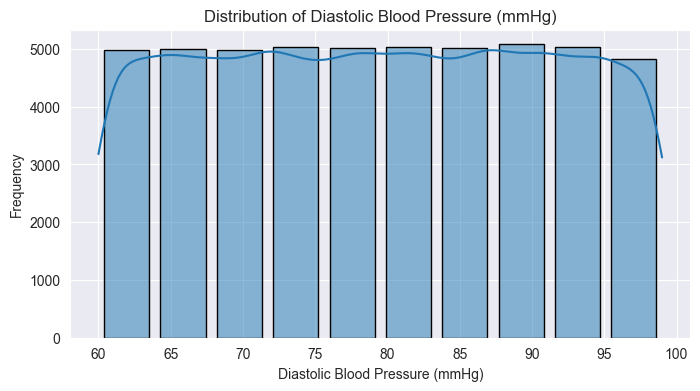

In [22]:
sns.histplot(data = iomt, x= 'Diastolic Blood Pressure (mmHg)', bins=10, kde = True, edgecolor='black', shrink=0.8)
plt.title('Distribution of Diastolic Blood Pressure (mmHg)')
plt.xlabel('Diastolic Blood Pressure (mmHg)')
plt.ylabel('Frequency')
plt.show()

**Histogram Readiings**

All vitals except Body Temperature are uniformly distributed, suggesting synthetic data generation. Body Temperature follows a normal distribution centered around 37°C.

**Box Plot**

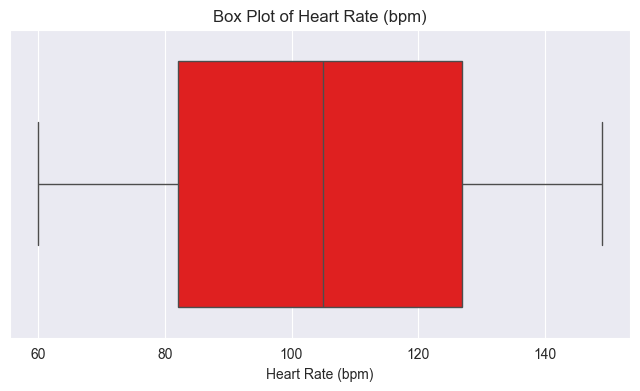

In [23]:
sns.boxplot(data = iomt, x = 'Heart Rate (bpm)', color = 'red')
plt.title('Box Plot of Heart Rate (bpm)')
plt.xlabel('Heart Rate (bpm)')
plt.show()

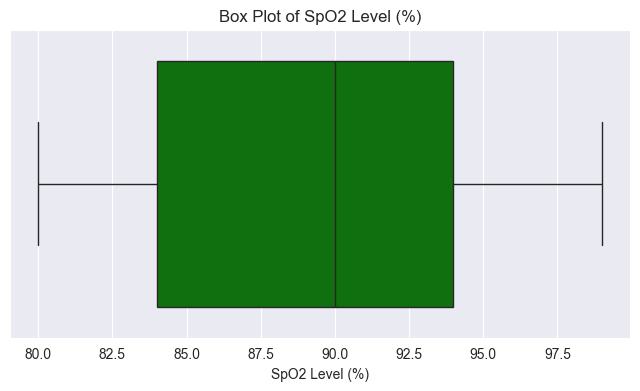

In [24]:
sns.boxplot(data = iomt, x = 'SpO2 Level (%)', color='green')
plt.title('Box Plot of SpO2 Level (%)')
plt.xlabel('SpO2 Level (%)')
plt.show()

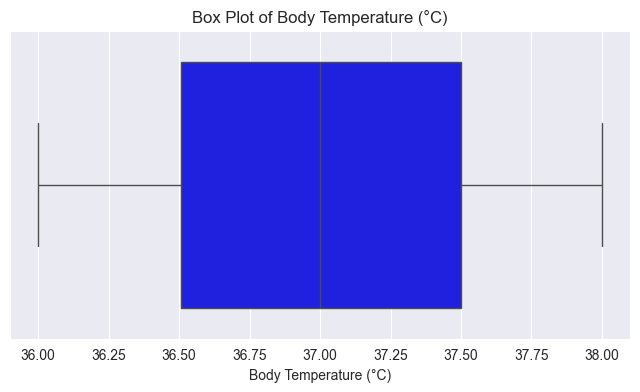

In [25]:
sns.boxplot(data= iomt, x= 'Body Temperature (°C)', color='blue')
plt.title('Box Plot of Body Temperature (°C)')
plt.xlabel('Body Temperature (°C)')
plt.show()

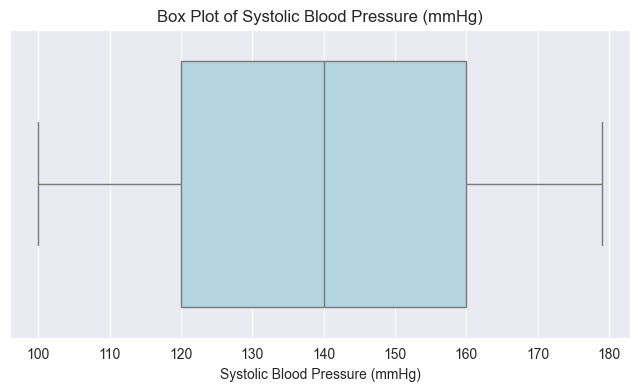

In [26]:
sns.boxplot(data = iomt, x='Systolic Blood Pressure (mmHg)', color='lightblue')
plt.title('Box Plot of Systolic Blood Pressure (mmHg)')
plt.xlabel('Systolic Blood Pressure (mmHg)')
plt.show()

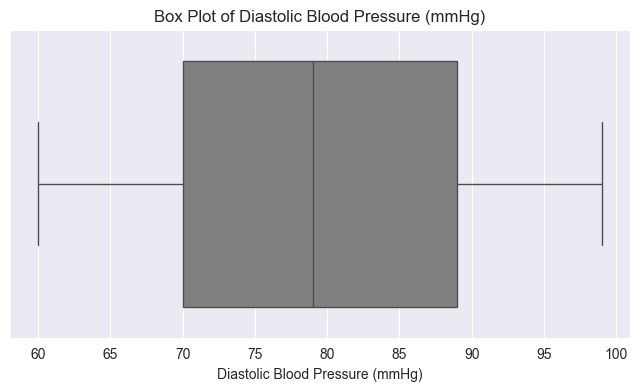

In [27]:
sns.boxplot(data=iomt, x='Diastolic Blood Pressure (mmHg)', color='grey')
plt.title('Box Plot of Diastolic Blood Pressure (mmHg)')
plt.xlabel('Diastolic Blood Pressure (mmHg)')
plt.show()

**Box Plot Observations**

There are no outliers from the plot, which confirms that the dataset is synthetic. 

while for the median reading for each vital is -

- Heart Rate - centre (symmetric).

- SpO₂ - slightly right of centre, indicating a slight left skew.

- Body Temperature - centre (symmetric), consistent with the normal distribution.

- Systolic - centre (symmetric).

- Diastolic - slightly left, which means more patients cluster toward lower diastolic values, slight right skew.

And from the reading, Systolic BP has the widest spread. 

**Correlation Heatmap**

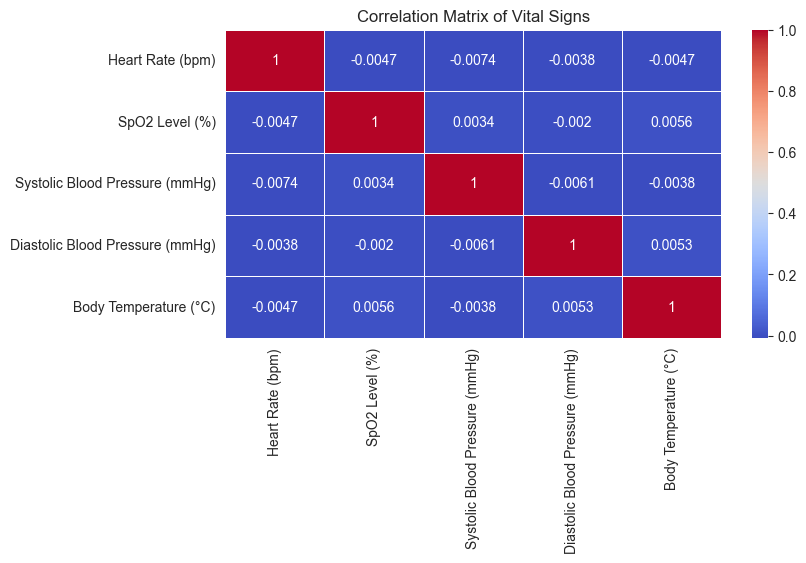

In [28]:
correlation_matrix = iomt[['Heart Rate (bpm)', 'SpO2 Level (%)', 'Systolic Blood Pressure (mmHg)', 'Diastolic Blood Pressure (mmHg)', 'Body Temperature (°C)']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Vital Signs')
plt.show()

Pair plot saved as 'iomt_pairplot.png' with 300 DPI resolution.


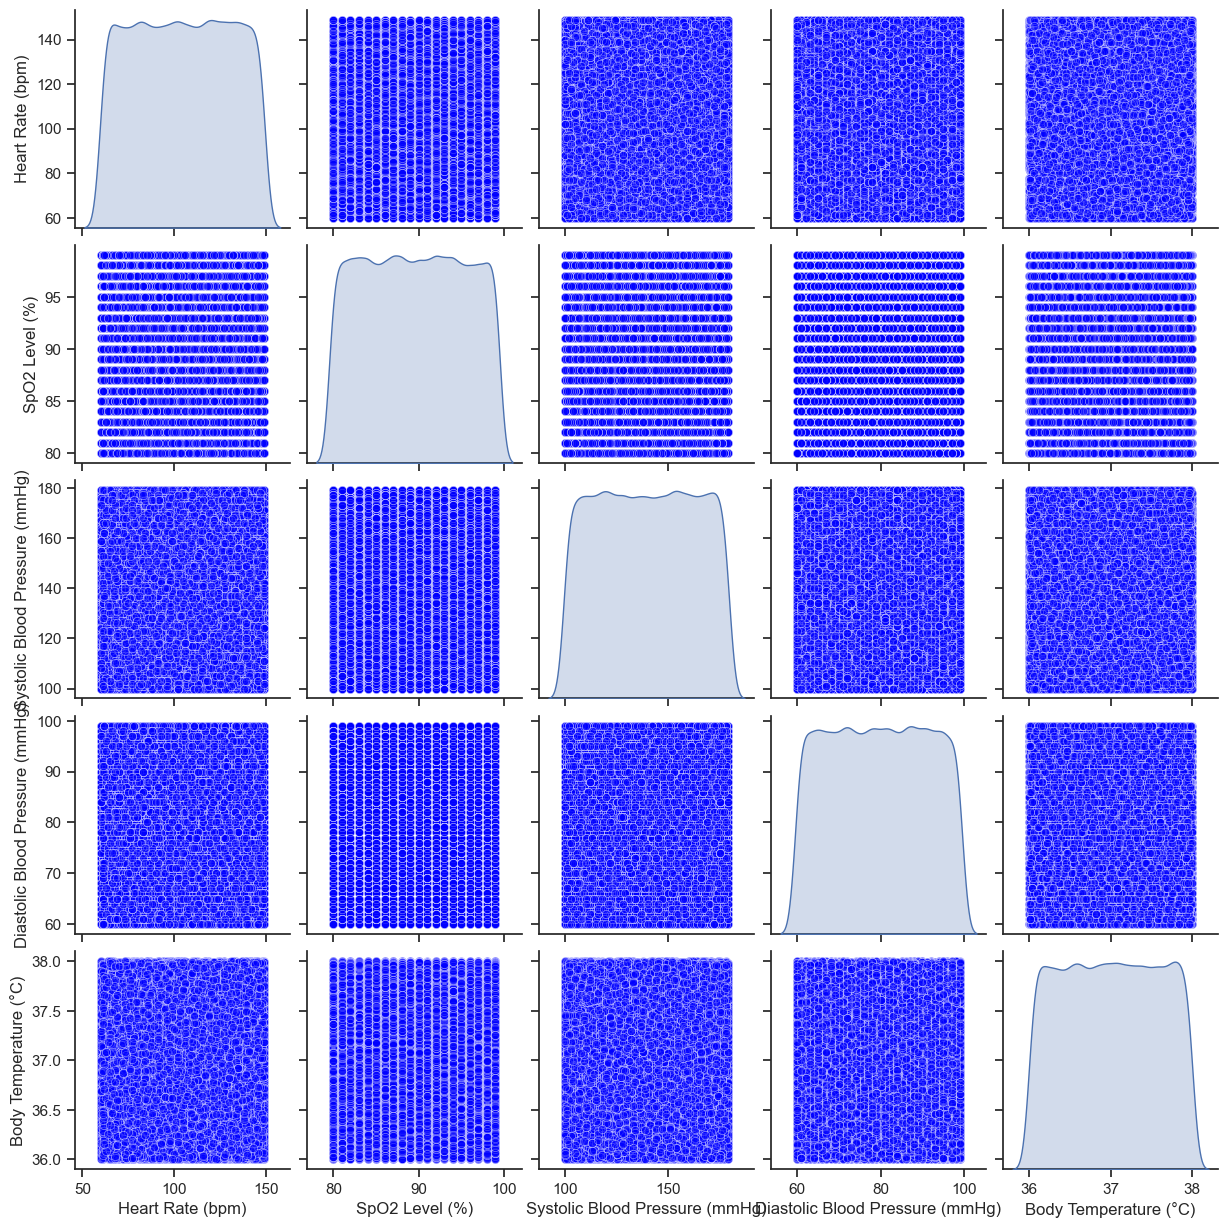

In [29]:
columns = ['Heart Rate (bpm)', 'SpO2 Level (%)', 'Systolic Blood Pressure (mmHg)', 'Diastolic Blood Pressure (mmHg)', 'Body Temperature (°C)']

df_iomt = iomt[columns]
sns.set_theme(style='ticks')
pair_plot = sns.pairplot(df_iomt, diag_kind='kde', plot_kws={'alpha': 0.5, 'color': 'blue'})
pair_plot.savefig("pairplot.png", dpi=300)
print("Pair plot saved as 'iomt_pairplot.png' with 300 DPI resolution.")

## Vital Signs Dataset Analysis

My report on the EDA above.

**1. The Problem with the Current Data**

After looking at the correlation matrix and the scatter plots, I have clear proof that this dataset is made of fake, randomly generated numbers (although indicated by the owner of the dataset on Kaggle).

Here is why:

- The Heatmap: In real life, vital signs connect with each other (for example, high blood pressure usually goes with a higher heart rate). In this heatmap, every single correlation number is almost exactly 0. This means the columns do not talk to each other at all.

- The Scatter Plots: Instead of showing curves, groups, or trends, the scatter plots look like solid, perfect blue squares. Also, the charts on the diagonal line show that the numbers are perfectly flat from their minimum to their maximum limits.

Conclusion: While the data lacks real-world correlations, it still provides a valid benchmark for anomaly detection based on clinical thresholds.

**2. Updated Model Strategy**

Because the data has no real patterns, I have to change the machine learning plans:

Isolation Forest (STILL USING): I will keep this model. It does not need variables to correlate to find anomalies. It works by cutting the data space into boxes, so it can still easily flag data points that sit at the very edge of the uniform limits.

PyTorch Neural Networks (STOPPING): I am removing PyTorch for now. Neural networks need real mathematical patterns to learn.

## Feature Engineering

In [30]:
iomt['Pulse Pressure (mmHg)'] = iomt['Systolic Blood Pressure (mmHg)'] - iomt['Diastolic Blood Pressure (mmHg)']

In [31]:
iomt['Mean Arterial Pressure (mmHg)'] = (iomt['Systolic Blood Pressure (mmHg)'] + 2 * iomt['Diastolic Blood Pressure (mmHg)']) / 3

In [32]:
iomt[['Pulse Pressure (mmHg)', 'Mean Arterial Pressure (mmHg)']].head()

,Pulse Pressure (mmHg),Mean Arterial Pressure (mmHg)
0,12,93.000000
1,18,91.000000
2,53,87.666667
3,70,120.333333
4,95,111.666667


In [33]:
iomt[['Pulse Pressure (mmHg)', 'Mean Arterial Pressure (mmHg)']].tail()

,Pulse Pressure (mmHg),Mean Arterial Pressure (mmHg)
49995,38,77.666667
49996,30,81.000000
49997,99,100.000000
49998,76,89.333333
49999,72,121.000000


In [34]:
iomt.head()

,Patient Number,Heart Rate (bpm),SpO2 Level (%),Systolic Blood Pressure (mmHg),Diastolic Blood Pressure (mmHg),Body Temperature (°C),Fall Detection,Predicted Disease,Data Accuracy (%),Heart Rate Alert,SpO2 Level Alert,Blood Pressure Alert,Temperature Alert,Pulse Pressure (mmHg),Mean Arterial Pressure (mmHg)
0,1,96,92,101,89,36.904680,No,Diabetes Mellitus,95,Normal,Normal,Normal,Normal,12,93.000000
1,2,76,83,103,85,37.254129,Yes,Asthma,91,Normal,Low,Normal,Abnormal,18,91.000000
2,3,92,88,123,70,36.539418,Yes,Asthma,86,Normal,Low,Normal,Normal,53,87.666667
3,4,137,84,167,97,37.018767,Yes,Asthma,99,High,Low,High,Normal,70,120.333333
4,5,76,81,175,80,37.328671,No,Normal,93,Normal,Low,High,Abnormal,95,111.666667


## Preprocessing 

Scaling all the numerical features, so that the model will treat them similarly. 

In [35]:
features = ['Heart Rate (bpm)', 'SpO2 Level (%)', 'Systolic Blood Pressure (mmHg)', 'Diastolic Blood Pressure (mmHg)', 'Body Temperature (°C)', 'Pulse Pressure (mmHg)', 'Mean Arterial Pressure (mmHg)']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(iomt[features])

In [36]:
scaled_features

array([[-0.32826933,  0.4338947 , -1.6706431 , ..., -0.16757922,
        -1.85958639, -0.6000121 ],
       [-1.0998127 , -1.12926419, -1.58394584, ...,  0.43829813,
        -1.6274309 , -0.78464996],
       [-0.482578  , -0.26084259, -0.71697329, ..., -0.80087504,
        -0.27319052, -1.09237972],
       ...,
       [-1.60131589,  0.26021038,  1.14701769, ...,  0.14303479,
         1.50666825,  0.04622039],
       [-0.3668465 , -0.78189555,  0.01995337, ...,  1.43202894,
         0.61673886, -0.93851484],
       [-1.06123553,  0.78126334,  1.27706357, ..., -0.51520406,
         0.46196854,  1.98491788]], shape=(50000, 7))

## Model - Isolation Forest

In [37]:
from sklearn.ensemble import IsolationForest

In [38]:
clf = IsolationForest(contamination=0.05, random_state=42)
clf.fit(scaled_features)
iomt['Anomaly'] = clf.predict(scaled_features)

In [39]:
predictions = iomt['Anomaly']
predictions.value_counts()

Anomaly
 1    47500
-1     2500
Name: count, dtype: int64

In [40]:
abnormal_data = np.where(predictions == -1)

In [41]:
x= iomt.values[abnormal_data]

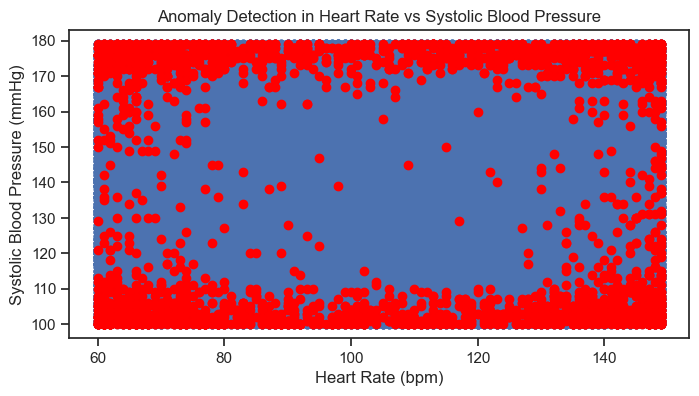

In [42]:
abnormal_data = np.where(predictions == -1)
plt.scatter(iomt.iloc[:, 1], iomt.iloc[:, 3])
plt.scatter(x[:, 1], x[:, 3], color='red')
plt.title('Anomaly Detection in Heart Rate vs Systolic Blood Pressure')
plt.xlabel('Heart Rate (bpm)')
plt.ylabel('Systolic Blood Pressure (mmHg)')
plt.show()

## Scatter Plot Reading 

1. The plot shows normal patients (which is the blue data points) and anomalies flagged by Isolation Forest is the red pat. 

2. The red points are concentrated at the edges, which indicates very high and very low systolic BP values.

3. And a few red points that appear in the middle, which are flagged due to other features, not just BP. 

4. This aligns with clinical expectations, that says extreme BP values are medically concerning. 

## Clinical Interpretation For The Model

The question this part is answering is "Are anomalies more likely to belong to certain diseases like Hypertension or Arrhythmia?"

In [43]:
pd.crosstab(iomt['Anomaly'], iomt['Predicted Disease'])

Predicted Disease,Arrhythmia,Asthma,Diabetes Mellitus,Hypertension,Normal
Anomaly,,,,,
-1,500,501,501,508,490
1,9445,9559,9551,9422,9523


This shows that the anomalies are not tied to any disease, but based on extreme vital signs regardless of what the patient has been labeled to have.

In [45]:
pd.crosstab(iomt['Anomaly'], [iomt['Heart Rate Alert'], iomt['SpO2 Level Alert'], iomt['Blood Pressure Alert'], iomt['Temperature Alert']])

Heart Rate Alert         High                                                  \
SpO2 Level Alert          Low                          Normal                   
Blood Pressure Alert     High          Normal            High          Normal   
Temperature Alert    Abnormal Normal Abnormal Normal Abnormal Normal Abnormal   
Anomaly                                                                         
-1                        306    217      121     78      229    128      135   
 1                       3340   4304     2322   3029     3507   4290     2313   

Heart Rate Alert              Normal                                         \
SpO2 Level Alert                 Low                          Normal          
Blood Pressure Alert            High          Normal            High          
Temperature Alert    Normal Abnormal Normal Abnormal Normal Abnormal Normal   
Anomaly                                                                       
-1                      101      292    178      107     53      214    113   
 1                     2892     2734   3648     1920   2332     2923   3717   

Heart Rate Alert                      
SpO2 Level Alert                      
Blood Pressure Alert   Normal         
Temperature Alert    Abnormal Normal  
Anomaly                               
-1                        154     74  
 1                       1869   2360

This answers the question...Do anomalies correspond to patients who already had a High/Low/Abnormal alert?

And from the code above, this means...

- When a patient has all 4 alerts abnormal, about 8.4% of them get flagged as anomalies by your model.

- When a patient has all 4 alerts normal, only about 3% get flagged.

That's roughly 3x higher anomaly rate in the "all bad alerts" group compared to the "all normal" group.

Even with the synthetic dataset, the Isolation Forest model does tend to agree more with the existing alert system when a patient has multiple abnormal readings simultaneously, compared to a patient with all normal readings.

## Interface

In [46]:
import joblib

joblib.dump(clf, 'isolation_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']